# Cellula Technologies — Task 1: Exploratory Data Analysis

## Project Objective

The objective of this task is to perform a comprehensive Exploratory Data Analysis (EDA) on Uber ride data.

The analysis focuses on:

- Understanding the structure and quality of the dataset.
- Identifying missing values, duplicates, and potential data quality issues.
- Exploring the distribution of the target variable, `Fare_Amount`.
- Investigating relationships between fare amount and different ride characteristics.
- Selecting appropriate visualizations for different analytical questions.
- Extracting meaningful insights that can guide the next stage of the project: Machine Learning modeling.

## 1. Dataset Description

The dataset contains real-world Uber ride records from New York City, where each row represents one trip.

The dataset includes information about:

- Passenger and driver-related attributes.
- Vehicle condition.
- Weather and traffic conditions.
- Pickup and drop-off locations.
- Trip distance and direction.
- Date and time information.
- Distance from major NYC landmarks and airports.
- The fare amount paid for each trip.

### Target Variable

`Fare_Amount` is the target variable representing the fare paid for the trip in USD.

### Important Identifiers

- `User_ID`: Unique user identifier.
- `Key`: Unique trip identifier used for deduplication.

`User_ID`, `User_Name`, and `Driver_Name` are identifiers or names and are not considered useful modeling features according to the task description.

## 2. Import Libraries

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Display options
from IPython.display import display

# Set a consistent visual style for all plots
sns.set_theme(style="whitegrid")
# Display all columns when inspecting the dataset
pd.set_option("display.max_columns", None)
# Improve the display of floating-point numbers
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## 3. Load Dataset

In [2]:
df = pd.read_csv("sample_50000.csv")
print("Dataset loaded successfully.")

Dataset loaded successfully.


## 4. Initial Data Inspection

Before performing any cleaning or analysis, we first inspect the dataset to understand:

- Its dimensions.
- The available columns.
- The first few records.
- The data types.
- The general structure of the dataset.

In [3]:
print(f"Number of rows    : {df.shape[0]:,}")
print(f"Number of columns : {df.shape[1]:,}")

Number of rows    : 50,000
Number of columns : 26


In [4]:
df.head()

,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,KHVrEVlD,Kimberly Adams,Amy Butler,Very Good,windy,Congested Traffic,2009-06-15 17:26:21,4.500,2009-06-15 17:26:21,-1.289,0.711,-1.289,0.711,1,17,15,6,0,2009,20.266,55.176,14.343,34.544,27.573,1.031,-2.919
1,lPxIuEri,Justin Tapia,Hannah Zimmerman,Excellent,cloudy,Flow Traffic,2010-01-05 16:52:16,16.900,2010-01-05 16:52:16,-1.292,0.711,-1.291,0.712,1,16,5,1,1,2010,44.668,31.832,23.131,15.126,8.756,8.450,-0.375
2,gsVN8JLS,Elizabeth Lopez,Amanda Jackson,Bad,stormy,Congested Traffic,2011-08-18 00:35:00,5.700,2011-08-18 00:35:00,-1.291,0.711,-1.291,0.711,2,0,18,8,3,2011,43.598,33.712,19.865,17.723,9.847,1.390,2.600
3,9I7kWFgd,Steven Wilson,Amy Horn,Very Good,stormy,Flow Traffic,2012-04-21 04:30:42,7.700,2012-04-21 04:30:42,-1.291,0.711,-1.291,0.711,1,4,21,4,5,2012,42.643,32.556,21.063,15.739,7.703,2.799,0.134
4,8QN5ZaGN,Alexander Andrews,Cassandra Larson,Bad,stormy,Congested Traffic,2010-03-09 07:51:00,5.300,2010-03-09 07:51:00,-1.291,0.712,-1.291,0.712,1,7,9,3,1,2010,43.330,39.407,15.219,23.732,15.601,1.999,-0.503


In [5]:
df.columns.tolist()

['User ID',
 'User Name',
 'Driver Name',
 'Car Condition',
 'Weather',
 'Traffic Condition',
 'key',
 'fare_amount',
 'pickup_datetime',
 'pickup_longitude',
 'pickup_latitude',
 'dropoff_longitude',
 'dropoff_latitude',
 'passenger_count',
 'hour',
 'day',
 'month',
 'weekday',
 'year',
 'jfk_dist',
 'ewr_dist',
 'lga_dist',
 'sol_dist',
 'nyc_dist',
 'distance',
 'bearing']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   User ID            50000 non-null  str    
 1   User Name          50000 non-null  str    
 2   Driver Name        50000 non-null  str    
 3   Car Condition      50000 non-null  str    
 4   Weather            50000 non-null  str    
 5   Traffic Condition  50000 non-null  str    
 6   key                50000 non-null  str    
 7   fare_amount        50000 non-null  float64
 8   pickup_datetime    50000 non-null  str    
 9   pickup_longitude   50000 non-null  float64
 10  pickup_latitude    50000 non-null  float64
 11  dropoff_longitude  50000 non-null  float64
 12  dropoff_latitude   50000 non-null  float64
 13  passenger_count    50000 non-null  int64  
 14  hour               50000 non-null  int64  
 15  day                50000 non-null  int64  
 16  month              50000 non-null

##  Dataset Structure Summary

The initial inspection shows that the sample dataset contains **50,000 ride records and 26 columns**.

The dataset includes:

- Categorical variables describing car condition, weather, and traffic.
- Numerical variables describing passenger count, distances, coordinates, and trip direction.
- Temporal variables such as hour, day, month, weekday, and year.
- `fare_amount` as the target variable.
- Pickup and drop-off geographic coordinates.
- Distance-related features such as airport distances, Statue of Liberty distance, NYC distance, and total trip distance.

At this stage, all columns contain 50,000 non-null values according to the initial dataset information.

In [7]:
# Missing Values Check

missing_values = df.isnull().sum()
missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (missing_values / len(df)) * 100
})

missing_summary = missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

missing_summary

,Missing Values,Missing Percentage
User ID,0,0.000
User Name,0,0.000
Driver Name,0,0.000
Car Condition,0,0.000
Weather,0,0.000
Traffic Condition,0,0.000
key,0,0.000
fare_amount,0,0.000
pickup_datetime,0,0.000
pickup_longitude,0,0.000


In [8]:
# Duplicate Records Check
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows:,}")


# Duplicate Trip IDs Check
duplicate_keys = df["key"].duplicated().sum()
print(f"Number of duplicated trip IDs: {duplicate_keys:,}")

Number of duplicate rows: 0
Number of duplicated trip IDs: 445


## 5. Data Quality Assessment

Before cleaning the dataset, we will assess its quality by checking:

- Missing values
- Duplicate records
- Duplicate trip identifiers

The purpose of this step is to identify potential data quality issues
before making any changes to the original data.

### Duplicate Trip ID Investigation

The dataset contains duplicate values in the `key` column, while
there are no completely duplicated rows.

Since `key` is described as a unique trip identifier, we need to
inspect these records before deciding whether they should be removed.

At this stage, no records will be deleted.

In [9]:
# Inspect Duplicate Trip IDs

duplicate_key_rows = df[df["key"].duplicated(keep=False)].sort_values("key")
duplicate_key_rows.head(20)

,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
32402,dUhwg9Fk,Matthew Parker,Daniel Gentry,Good,windy,Congested Traffic,2009-01-06 13:33:00,50.000,2009-01-06 13:33:00,-1.291,0.711,-1.288,0.709,1,13,6,1,1,2009,21.902,50.307,24.770,31.490,25.089,19.415,-2.237
38749,3Q3x3fpk,Deborah Cunningham,Robert Perkins,Very Good,windy,Congested Traffic,2009-01-06 13:33:00,7.300,2009-01-06 13:33:00,-1.291,0.712,-1.291,0.712,1,13,6,1,1,2009,43.348,39.955,14.887,24.293,16.145,2.362,-0.395
630,HK4IBTEV,Daniel Franco,Karina Roberts,Good,rainy,Dense Traffic,2009-01-10 16:28:00,2.900,2009-01-10 16:28:00,-1.291,0.711,-1.291,0.711,1,16,10,1,5,2009,42.276,35.507,17.978,19.027,10.857,0.257,-1.969
25829,6YRcYerF,Kathleen Cervantes,Amanda Hines,Good,windy,Flow Traffic,2009-01-10 16:28:00,4.900,2009-01-10 16:28:00,-1.291,0.712,-1.291,0.712,5,16,10,1,5,2009,44.048,43.545,12.841,28.242,20.070,1.197,-3.036
13423,4bnwLsAX,Adam Levine,Susan Lester,Very Good,windy,Congested Traffic,2009-02-01 15:14:00,7.300,2009-02-01 15:14:00,-1.291,0.711,-1.291,0.711,1,15,1,2,6,2009,40.819,36.261,17.143,19.067,10.696,2.184,2.496
38789,2YKV3kSh,Jeffrey Morales,Benjamin Vasquez,Good,cloudy,Flow Traffic,2009-02-01 15:14:00,6.500,2009-02-01 15:14:00,-1.291,0.711,-1.291,0.712,1,15,1,2,6,2009,42.258,37.537,16.200,21.277,13.083,1.270,-1.332
2905,RwWWhGl2,Donna Rangel,Heather Reed,Very Good,windy,Dense Traffic,2009-02-01 23:18:00,9.300,2009-02-01 23:18:00,-1.291,0.712,-1.292,0.711,2,23,1,2,6,2009,45.212,34.471,20.191,19.209,11.659,5.528,2.637
40935,nFzLh9AE,Wendy Barber,Tracie Martinez,Excellent,cloudy,Dense Traffic,2009-02-01 23:18:00,3.700,2009-02-01 23:18:00,-1.291,0.711,-1.291,0.711,2,23,1,2,6,2009,41.820,33.188,20.148,16.049,7.843,0.759,-2.068
28243,liPE8zKv,Connie Cole DDS,Billy Oliver,Bad,cloudy,Flow Traffic,2009-02-05 22:32:00,4.500,2009-02-05 22:32:00,-1.291,0.711,-1.291,0.711,1,22,5,2,3,2009,41.005,35.458,17.897,18.259,9.912,1.417,2.497
47268,fNfeWFSS,Karl King,Timothy Ramos,Bad,sunny,Flow Traffic,2009-02-05 22:32:00,6.500,2009-02-05 22:32:00,-1.292,0.711,-1.292,0.711,1,22,5,2,3,2009,42.997,29.062,24.412,11.492,3.788,1.406,2.395


In [10]:
print(f"Rows with duplicated trip IDs: {len(duplicate_key_rows):,}")

Rows with duplicated trip IDs: 886


In [11]:
duplicate_key_rows.head(20)

,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
32402,dUhwg9Fk,Matthew Parker,Daniel Gentry,Good,windy,Congested Traffic,2009-01-06 13:33:00,50.000,2009-01-06 13:33:00,-1.291,0.711,-1.288,0.709,1,13,6,1,1,2009,21.902,50.307,24.770,31.490,25.089,19.415,-2.237
38749,3Q3x3fpk,Deborah Cunningham,Robert Perkins,Very Good,windy,Congested Traffic,2009-01-06 13:33:00,7.300,2009-01-06 13:33:00,-1.291,0.712,-1.291,0.712,1,13,6,1,1,2009,43.348,39.955,14.887,24.293,16.145,2.362,-0.395
630,HK4IBTEV,Daniel Franco,Karina Roberts,Good,rainy,Dense Traffic,2009-01-10 16:28:00,2.900,2009-01-10 16:28:00,-1.291,0.711,-1.291,0.711,1,16,10,1,5,2009,42.276,35.507,17.978,19.027,10.857,0.257,-1.969
25829,6YRcYerF,Kathleen Cervantes,Amanda Hines,Good,windy,Flow Traffic,2009-01-10 16:28:00,4.900,2009-01-10 16:28:00,-1.291,0.712,-1.291,0.712,5,16,10,1,5,2009,44.048,43.545,12.841,28.242,20.070,1.197,-3.036
13423,4bnwLsAX,Adam Levine,Susan Lester,Very Good,windy,Congested Traffic,2009-02-01 15:14:00,7.300,2009-02-01 15:14:00,-1.291,0.711,-1.291,0.711,1,15,1,2,6,2009,40.819,36.261,17.143,19.067,10.696,2.184,2.496
38789,2YKV3kSh,Jeffrey Morales,Benjamin Vasquez,Good,cloudy,Flow Traffic,2009-02-01 15:14:00,6.500,2009-02-01 15:14:00,-1.291,0.711,-1.291,0.712,1,15,1,2,6,2009,42.258,37.537,16.200,21.277,13.083,1.270,-1.332
2905,RwWWhGl2,Donna Rangel,Heather Reed,Very Good,windy,Dense Traffic,2009-02-01 23:18:00,9.300,2009-02-01 23:18:00,-1.291,0.712,-1.292,0.711,2,23,1,2,6,2009,45.212,34.471,20.191,19.209,11.659,5.528,2.637
40935,nFzLh9AE,Wendy Barber,Tracie Martinez,Excellent,cloudy,Dense Traffic,2009-02-01 23:18:00,3.700,2009-02-01 23:18:00,-1.291,0.711,-1.291,0.711,2,23,1,2,6,2009,41.820,33.188,20.148,16.049,7.843,0.759,-2.068
28243,liPE8zKv,Connie Cole DDS,Billy Oliver,Bad,cloudy,Flow Traffic,2009-02-05 22:32:00,4.500,2009-02-05 22:32:00,-1.291,0.711,-1.291,0.711,1,22,5,2,3,2009,41.005,35.458,17.897,18.259,9.912,1.417,2.497
47268,fNfeWFSS,Karl King,Timothy Ramos,Bad,sunny,Flow Traffic,2009-02-05 22:32:00,6.500,2009-02-05 22:32:00,-1.292,0.711,-1.292,0.711,1,22,5,2,3,2009,42.997,29.062,24.412,11.492,3.788,1.406,2.395


### Duplicate Key Frequency

To better understand the duplicated trip identifiers, we will examine
how many times each duplicated `key` appears in the dataset.

This helps determine whether the duplicated identifiers are isolated
duplicates or occur multiple times.

In [12]:
# Frequency of Duplicate Trip IDs

duplicate_key_counts = (
    df["key"]
    .value_counts()
    .loc[lambda x: x > 1]
)
duplicate_key_counts.describe()

count   441.000
mean      2.009
std       0.095
min       2.000
25%       2.000
50%       2.000
75%       2.000
max       3.000
Name: count, dtype: float64

In [13]:
duplicate_key_counts.head(10)

key
2012-06-28 20:54:00    3
2011-09-03 01:30:00    3
2014-05-30 23:38:00    3
2011-02-11 13:19:00    3
2009-12-10 15:37:00    2
2014-12-07 12:26:00    2
2012-12-06 18:05:00    2
2014-09-12 23:10:00    2
2012-02-12 01:26:00    2
2011-04-04 18:56:00    2
Name: count, dtype: int64

### Understanding the `key` Column

The `key` column is expected to represent a unique trip identifier
according to the task description.

However, the duplicated values observed in the sample dataset appear
to be timestamp-like values.

Therefore, we will inspect the relationship between `key` and
`pickup_datetime` before making any cleaning decision.

In [14]:
# Compare Key with Pickup Datetime

key_datetime_comparison = df[["key", "pickup_datetime"]].head(10)
key_datetime_comparison

,key,pickup_datetime
0,2009-06-15 17:26:21,2009-06-15 17:26:21
1,2010-01-05 16:52:16,2010-01-05 16:52:16
2,2011-08-18 00:35:00,2011-08-18 00:35:00
3,2012-04-21 04:30:42,2012-04-21 04:30:42
4,2010-03-09 07:51:00,2010-03-09 07:51:00
5,2011-01-06 09:50:45,2011-01-06 09:50:45
6,2012-11-20 20:35:00,2012-11-20 20:35:00
7,2012-01-04 17:22:00,2012-01-04 17:22:00
8,2012-12-03 13:10:00,2012-12-03 13:10:00
9,2009-09-02 01:11:00,2009-09-02 01:11:00


In [15]:
# Check Whether Key Matches Pickup Datetime

key_matches_datetime = (
    df["key"].astype(str) == df["pickup_datetime"].astype(str)
).mean()

print(f"Percentage of rows where key matches pickup_datetime: "
      f"{key_matches_datetime:.2%}")

Percentage of rows where key matches pickup_datetime: 100.00%


### Checking Fare Amount

`fare_amount` is the target variable of the project.

Before starting the exploratory analysis, we need to check its
distribution and identify whether there are any unusual or invalid
values that may affect the analysis.

At this stage, we will inspect the minimum, maximum, and basic
descriptive statistics without removing any records.

In [16]:
df["fare_amount"].describe()

count   50,000.000
mean        11.364
std          9.686
min         -5.000
25%          6.000
50%          8.500
75%         12.500
max        200.000
Name: fare_amount, dtype: float64

In [17]:
# Count Non-Positive Fare Values

non_positive_fares = (df["fare_amount"] <= 0).sum()
print(f"Number of non-positive fares: {non_positive_fares:,}")
print(f"Percentage of non-positive fares: "
      f"{non_positive_fares / len(df):.2%}")

Number of non-positive fares: 9
Percentage of non-positive fares: 0.02%


In [18]:
# Inspect Non-Positive Fare Records

non_positive_fare_rows = df[df["fare_amount"] <= 0]
non_positive_fare_rows[
    [
        "fare_amount",
        "pickup_datetime",
        "passenger_count",
        "distance",
        "pickup_longitude",
        "pickup_latitude",
        "dropoff_longitude",
        "dropoff_latitude"
    ]
]

,fare_amount,pickup_datetime,passenger_count,distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
2039,-2.900,2010-03-09 23:37:10,1,0.184,-1.288,0.709,-1.288,0.709
2486,-2.500,2015-03-22 05:14:27,1,0.021,-1.292,0.711,-1.292,0.711
10002,0.000,2010-02-15 14:26:01,1,3.185,-1.291,0.711,-1.292,0.711
13032,-3.000,2013-08-30 08:57:10,4,0.096,-1.291,0.711,-1.291,0.711
27891,0.000,2015-05-15 21:40:28,1,0.001,-1.293,0.712,-1.293,0.712
28839,-2.500,2013-08-11 13:39:10,1,"8,647.452",-1.288,0.709,0.000,0.000
36722,-2.500,2015-04-30 15:19:45,1,0.353,-1.291,0.712,-1.291,0.712
42337,-5.000,2015-03-09 10:29:46,1,0.958,-1.291,0.711,-1.291,0.711
47302,0.000,2010-03-18 19:13:39,1,0.018,-1.291,0.712,-1.291,0.712


### Data Quality Finding: Fare Amount

The `fare_amount` column contains 9 non-positive values, representing
0.02% of the dataset.

Since fare amount represents the trip price, negative and zero values
are not valid for fare analysis.

These records are flagged for exclusion from the final fare analysis.
However, the original `df` will be preserved during the data quality
assessment so that no information is removed before all quality checks
are completed.

One of the affected records also contains an unusually large `distance`
value and coordinates equal to zero. These issues will be investigated
separately.

In [19]:
# Passenger Count Summary
df["passenger_count"].describe()

count   50,000.000
mean         1.668
std          1.289
min          0.000
25%          1.000
50%          1.000
75%          2.000
max          6.000
Name: passenger_count, dtype: float64

In [20]:
# Count Zero Passenger Records

zero_passengers = (df["passenger_count"] == 0).sum()

print(f"Number of records with zero passengers: {zero_passengers:,}")
print(f"Percentage of records with zero passengers: "
      f"{zero_passengers / len(df):.2%}")

Number of records with zero passengers: 165
Percentage of records with zero passengers: 0.33%


In [21]:
# Inspect Zero Passenger Records

zero_passenger_rows = df[df["passenger_count"] == 0]

zero_passenger_rows[
    [
        "fare_amount",
        "pickup_datetime",
        "passenger_count",
        "distance",
        "pickup_longitude",
        "pickup_latitude",
        "dropoff_longitude",
        "dropoff_latitude"
    ]
].head(10)

,fare_amount,pickup_datetime,passenger_count,distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
314,34.000,2015-06-02 23:16:15,0,15.578,-1.291,0.711,-1.290,0.714
566,4.900,2012-01-28 21:33:18,0,1.020,-1.291,0.712,-1.291,0.712
678,6.500,2012-02-27 07:24:20,0,2.427,-1.291,0.711,-1.291,0.711
1160,13.300,2011-05-25 23:58:48,0,6.003,-1.292,0.711,-1.291,0.712
1935,10.100,2011-10-23 11:09:28,0,2.950,-1.291,0.712,-1.291,0.712
2200,8.100,2011-05-23 16:54:19,0,1.796,-1.291,0.711,-1.292,0.711
2425,8.900,2011-11-25 22:47:33,0,2.517,-1.292,0.711,-1.291,0.711
3034,5.700,2011-03-06 12:03:14,0,1.880,-1.291,0.711,-1.291,0.711
3413,7.300,2011-02-28 06:39:16,0,1.022,-1.291,0.711,-1.291,0.711
3481,11.300,2011-11-30 17:23:02,0,1.384,-1.291,0.711,-1.291,0.711


### Data Quality Finding: Passenger Count

The `passenger_count` column contains 165 records with a value of zero,
representing 0.33% of the dataset.

Inspection of sample records shows that these trips can still contain
valid-looking fare amounts and trip distances.

Therefore, zero passenger counts are treated as a data-quality anomaly,
but the records will not be removed at this stage. The final handling
decision will be documented after completing the remaining data quality
checks.

In [22]:
df["distance"].describe()

count   50,000.000
mean        18.509
std        355.564
min          0.000
25%          1.223
50%          2.120
75%          3.896
max      8,667.819
Name: distance, dtype: float64

In [23]:
# Count Zero Distance Records
zero_distance = (df["distance"] == 0).sum()

print(f"Number of zero-distance records: {zero_distance:,}")
print(f"Percentage of zero-distance records: "
      f"{zero_distance / len(df):.2%}")

Number of zero-distance records: 1,449
Percentage of zero-distance records: 2.90%


### Investigating Zero-Distance Records

There are 1,449 records with a distance of zero, representing 2.90%
of the dataset.

To understand whether these records are potentially valid or indicate
a data-quality issue, we will compare their pickup and dropoff
coordinates.

In [24]:
zero_distance_rows = df[df["distance"] == 0]

zero_distance_rows[
    [
        "fare_amount",
        "passenger_count",
        "pickup_longitude",
        "pickup_latitude",
        "dropoff_longitude",
        "dropoff_latitude",
        "distance"
    ]
].head(10)

,fare_amount,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,distance
11,5.500,3,0.000,0.000,0.000,0.000,0.000
15,5.000,1,0.000,0.000,0.000,0.000,0.000
26,6.500,1,0.000,0.000,0.000,0.000,0.000
105,52.000,1,-1.292,0.711,-1.292,0.711,0.000
124,8.000,2,0.000,0.000,0.000,0.000,0.000
191,6.500,1,-1.292,0.711,-1.292,0.711,0.000
192,3.700,5,0.000,0.000,0.000,0.000,0.000
233,8.500,2,0.000,0.000,0.000,0.000,0.000
270,7.500,1,-1.291,0.711,-1.291,0.711,0.000
273,8.100,4,0.000,0.000,0.000,0.000,0.000


In [25]:
# Count Records with Zero Coordinates

zero_coordinates = (
    (df["pickup_longitude"] == 0) &
    (df["pickup_latitude"] == 0) &
    (df["dropoff_longitude"] == 0) &
    (df["dropoff_latitude"] == 0)
).sum()

print(f"Number of records with all-zero coordinates: {zero_coordinates:,}")
print(f"Percentage of dataset: "
      f"{zero_coordinates / len(df):.2%}")

Number of records with all-zero coordinates: 914
Percentage of dataset: 1.83%


In [26]:
# Count Records with Matching Pickup and Dropoff Coordinates

matching_coordinates = (
    (df["pickup_longitude"] == df["dropoff_longitude"]) &
    (df["pickup_latitude"] == df["dropoff_latitude"])
).sum()

print(f"Number of records with matching coordinates: {matching_coordinates:,}")
print(f"Percentage of dataset: "
      f"{matching_coordinates / len(df):.2%}")

Number of records with matching coordinates: 1,449
Percentage of dataset: 2.90%


### Data Quality Finding: Zero Distance

There are 1,449 records with a distance of zero, representing 2.90%
of the dataset.

All zero-distance records have matching pickup and dropoff coordinates.

Among these records, 914 have all pickup and dropoff coordinates equal
to zero, while the remaining records have matching non-zero coordinates.

Therefore, zero distance and zero coordinates are treated as separate
data-quality findings and will not be removed automatically at this stage.

### Geographic Coordinate Quality Note

The dataset contains **914 records where all four pickup/drop-off coordinates are zero**, and **1,449 records where pickup and drop-off coordinates are identical**, producing `distance = 0`. These records are retained in the original data and are only excluded from clearly labeled robustness checks when non-zero, finite coordinates are required.

The extreme-distance investigation also found suspicious coordinate patterns. Because not every extreme distance could be confirmed as invalid, extreme values are not automatically deleted.


### Identifying Extreme Distance Values

The distance distribution contains a very large maximum value compared
with the upper quartile.

To identify statistically extreme observations, we will use the
Interquartile Range (IQR) method.

IQR = Q3 - Q1

An observation is considered an upper extreme value when it is greater
than:

Q3 + 1.5 × IQR

In [27]:
# Calculate Distance IQR and Upper Bound

Q1 = df["distance"].quantile(0.25)
Q3 = df["distance"].quantile(0.75)

IQR = Q3 - Q1
upper_bound = Q3 + (1.5 * IQR)

print(f"Q1: {Q1:.3f}")
print(f"Q3: {Q3:.3f}")
print(f"IQR: {IQR:.3f}")
print(f"Upper bound: {upper_bound:.3f}")

Q1: 1.223
Q3: 3.896
IQR: 2.672
Upper bound: 7.904


In [28]:
# Count Extreme Distance Values

extreme_distance = (df["distance"] > upper_bound).sum()

print(f"Number of extreme distance records: {extreme_distance:,}")
print(f"Percentage of dataset: "
      f"{extreme_distance / len(df):.2%}")

Number of extreme distance records: 4,254
Percentage of dataset: 8.51%


In [29]:
# Inspect the Largest Distance Values

largest_distance_rows = (
    df.nlargest(10, "distance")
)

largest_distance_rows[
    [
        "distance",
        "fare_amount",
        "passenger_count",
        "pickup_longitude",
        "pickup_latitude",
        "dropoff_longitude",
        "dropoff_latitude",
        "pickup_datetime"
    ]
]

,distance,fare_amount,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,pickup_datetime
48996,"8,667.819",49.800,1,-1.292,0.711,0.000,0.000,2012-05-12 10:48:00
31823,"8,667.572",52.000,1,-1.292,0.711,0.000,0.000,2013-11-26 18:12:00
9147,"8,667.542",8.500,1,0.000,0.000,-1.292,0.711,2014-07-14 21:37:29
37798,"8,667.534",22.500,1,-1.292,0.711,0.000,0.000,2013-08-28 12:11:00
8647,"8,667.498",21.500,1,-1.292,0.711,0.000,0.000,2014-03-27 18:01:00
2397,"8,667.454",45.000,2,0.000,0.000,-1.292,0.711,2012-06-24 17:11:10
472,"8,667.305",2.500,2,0.000,0.000,-1.292,0.711,2009-02-22 22:48:00
46463,"8,667.135",5.500,5,-1.292,0.711,0.000,0.000,2012-11-14 23:02:00
42606,"8,667.123",3.700,0,-1.292,0.711,0.000,0.000,2012-01-18 22:37:47
21085,"8,667.103",21.000,1,-1.292,0.711,0.000,0.000,2012-10-17 12:37:00


In [30]:
# Check Zero Coordinates Among Extreme Distances

extreme_distance_rows = df[df["distance"] > upper_bound]

extreme_with_zero_coordinates = (
    (extreme_distance_rows["pickup_longitude"] == 0) &
    (extreme_distance_rows["pickup_latitude"] == 0)
) | (
    (extreme_distance_rows["dropoff_longitude"] == 0) &
    (extreme_distance_rows["dropoff_latitude"] == 0)
)

zero_coordinate_extremes = extreme_with_zero_coordinates.sum()

print(
    f"Extreme distance records with zero coordinates: "
    f"{zero_coordinate_extremes:,}"
)

print(
    f"Percentage of extreme distance records: "
    f"{zero_coordinate_extremes / len(extreme_distance_rows):.2%}"
)

Extreme distance records with zero coordinates: 80
Percentage of extreme distance records: 1.88%


In [31]:
# Inspect Extreme Distances with Non-Zero Coordinates

extreme_non_zero_coordinates = extreme_distance_rows[
    ~(
        (
            (extreme_distance_rows["pickup_longitude"] == 0) &
            (extreme_distance_rows["pickup_latitude"] == 0)
        )
        |
        (
            (extreme_distance_rows["dropoff_longitude"] == 0) &
            (extreme_distance_rows["dropoff_latitude"] == 0)
        )
    )
]

extreme_non_zero_coordinates.nlargest(10, "distance")[
    [
        "distance",
        "fare_amount",
        "passenger_count",
        "pickup_longitude",
        "pickup_latitude",
        "dropoff_longitude",
        "dropoff_latitude",
        "pickup_datetime"
    ]
]

,distance,fare_amount,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,pickup_datetime
48058,"8,665.602",8.500,3,-0.000,0.000,-1.291,0.711,2012-05-18 09:40:00
21303,"8,664.280",11.700,1,-0.000,0.000,-1.291,0.711,2012-05-22 08:37:00
41500,"6,034.863",14.900,1,-1.291,0.711,0.000,0.710,2010-10-17 03:26:00
17825,"6,032.058",16.500,1,0.000,0.711,-1.291,0.711,2012-06-05 09:11:00
15749,"6,028.927",10.900,1,-1.291,0.712,0.000,0.711,2012-05-12 17:58:00
2280,"6,026.494",8.900,1,-1.290,0.711,0.000,0.711,2011-08-29 08:24:00
34448,"6,023.890",11.700,2,-1.291,0.711,-0.002,0.711,2012-03-18 21:23:00
36910,"6,019.654",6.100,2,-1.291,0.712,-0.002,0.711,2012-03-15 16:56:00
24958,"5,729.879",10.900,1,-1.291,0.711,-0.069,0.712,2012-01-02 18:32:00
5864,"5,420.989",8.500,1,-1.291,0.711,-0.139,0.711,2012-03-04 01:35:00


In [32]:
# Inspect Extreme Coordinates at Higher Precision

extreme_non_zero_coordinates.nlargest(10, "distance")[
    [
        "distance",
        "pickup_longitude",
        "pickup_latitude",
        "dropoff_longitude",
        "dropoff_latitude"
    ]
].to_string(
    float_format=lambda x: f"{x:.12f}"
)

'               distance  pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude\n48058 8665.602468530438   -0.000029094639   0.000000000000    -1.291203272365    0.711241601848\n21303 8664.279910364008   -0.000407237674   0.000000000000    -1.291387579134    0.710898382850\n41500 6034.863450116791   -1.291305932632   0.710740081487     0.000000000000    0.710335514167\n17825 6032.057758969500    0.000000000000   0.711134002299    -1.291345115273    0.711000187906\n15749 6028.926779049152   -1.290970881775   0.711612676300     0.000000000000    0.711058953142\n2280  6026.494215729918   -1.290438277101   0.711358067669     0.000000000000    0.711358067669\n34448 6023.889765419144   -1.291429973182   0.711348154199    -0.002036223278    0.710684318218\n36910 6019.654329322773   -1.291157265486   0.711635924086    -0.002036223278    0.711484202614\n24958 5729.878792035809   -1.291398382722   0.710960167506    -0.069105299442    0.711561660326\n5864  5420.988958578794   -1.

In [33]:
# Unique Values in Categorical Variables

categorical_columns = [
    "Car Condition",
    "Weather",
    "Traffic Condition"
]

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts(dropna=False))


Car Condition
Car Condition
Good         12543
Bad          12537
Very Good    12484
Excellent    12436
Name: count, dtype: int64

Weather
Weather
sunny     10110
stormy    10017
rainy     10010
windy      9959
cloudy     9904
Name: count, dtype: int64

Traffic Condition
Traffic Condition
Flow Traffic         16698
Dense Traffic        16657
Congested Traffic    16645
Name: count, dtype: int64


### Data Quality Note: Dataset vs Task Description

The official task description lists simpler example category sets, but the actual CSV contains the categories observed above (for example, four car-condition levels, five weather levels, and three traffic levels). The analysis uses the **actual CSV values** and does not overwrite them to match the task description.

The same principle is applied to `key`: although the PDF describes it as a unique trip ID, the actual data contains duplicate keys and `key` matches `pickup_datetime` for all observed rows. Duplicate keys are therefore documented rather than arbitrarily deleted.


In [34]:
# Prepare Data for EDA

# Keep the original dataset `df` unchanged.
# Use a separate dataframe for fare-based EDA by excluding non-positive fares.
df_eda = df[df["fare_amount"] > 0].copy()

print(f"Original dataset size: {len(df):,}")
print(f"EDA dataset size: {len(df_eda):,}")
print(f"Removed records: {len(df) - len(df_eda):,}")


Original dataset size: 50,000
EDA dataset size: 49,991
Removed records: 9


In [35]:
# Convert Pickup Datetime

df_eda["pickup_datetime"] = pd.to_datetime(
    df_eda["pickup_datetime"],
    errors="coerce"
)

df_eda["pickup_datetime"].dtype

dtype('<M8[us]')

## 6. Exploratory Data Analysis

## Question 1: Does a Higher Passenger Count Lead to a Higher Fare?

### Variables
- `passenger_count`
- `fare_amount`

### Plot Choice
A scatter plot will be used because both variables are numerical.

### Objective
To investigate whether there is a visible relationship between the
number of passengers and the fare amount.
### Cleaning / Analysis Note
Only records with positive `fare_amount` are used in `df_eda`; the original `df` is preserved. No passenger-count or categorical records were removed for this question.


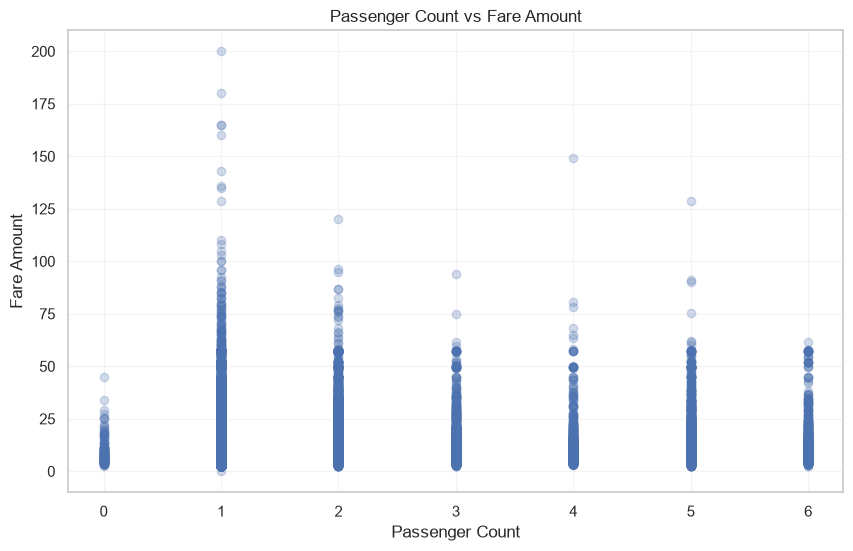

In [36]:
# Q1 - Passenger Count vs Fare

plt.figure(figsize=(10, 6))

plt.scatter(
    df_eda["passenger_count"],
    df_eda["fare_amount"],
    alpha=0.25
)

plt.xlabel("Passenger Count")
plt.ylabel("Fare Amount")
plt.title("Passenger Count vs Fare Amount")
plt.grid(alpha=0.2)

plt.show()

### Interpretation

The scatter plot shows a very weak relationship between passenger count and fare amount.

The Passenger-Fare correlation is approximately **0.017**, which is very close to zero. This indicates that passenger count alone does not show a meaningful linear relationship with fare amount in this sample.

Therefore, a higher passenger count does not appear to be associated with a substantially higher fare.

## Question 2: How Does Car Condition Influence Fare?

### Variables
- `Car Condition`
- `fare_amount`

### Plot Choice
A boxplot is used to compare the fare distributions across car
condition categories.

### Objective
To examine whether fare amounts differ across different car
conditions.
### Cleaning / Analysis Note
The comparison uses the positive-fare EDA dataset. Car-condition categories are kept exactly as they appear in the actual CSV.


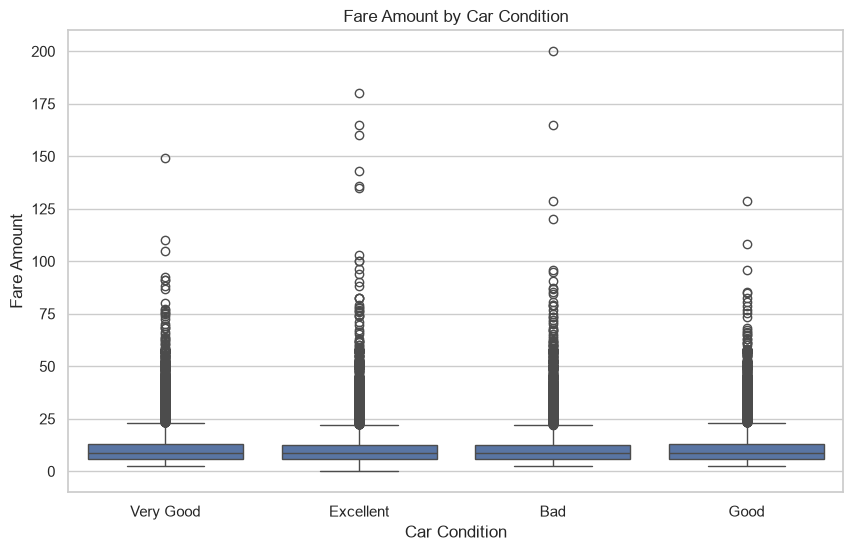

In [37]:
# Q2 - Car Condition vs Fare

plt.figure(figsize=(10, 6))

sns.boxplot(
    color="C0",
    data=df_eda,
    x="Car Condition",
    y="fare_amount"
)

plt.xlabel("Car Condition")
plt.ylabel("Fare Amount")
plt.title("Fare Amount by Car Condition")

plt.show()

In [38]:
df_eda.groupby("Car Condition")["fare_amount"].mean().sort_values(
    ascending=False
).round(2)

Car Condition
Bad         11.490
Very Good   11.440
Good        11.310
Excellent   11.220
Name: fare_amount, dtype: float64

### Interpretation

The boxplot shows substantial overlap between the fare distributions for the different car-condition categories.

The average fares are also very close: **Bad = 11.49**, **Very Good = 11.44**, **Good = 11.31**, and **Excellent = 11.22**.

This suggests that car condition does not show a large difference in fare amount within this dataset.

## Question 3: Which Hours Have the Highest Average Fares?

### Variables
- `hour`
- `fare_amount`

### Plot Choice
A line plot is appropriate because hours follow an ordered sequence
from 0 to 23.

### Objective
To identify how the average fare changes throughout the day.
### Cleaning / Analysis Note
The analysis uses the existing `hour` feature. The 5 AM result should be interpreted together with the number of observations at each hour.


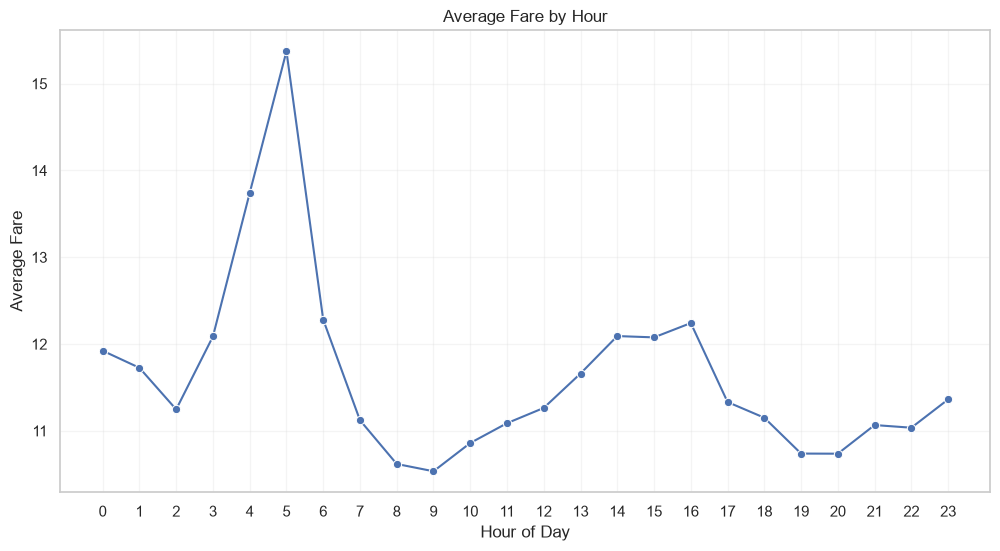

In [39]:
# Q3 - Average Fare by Hour

hourly_fare = (
    df_eda.groupby("hour")["fare_amount"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    color="C0",
    data=hourly_fare,
    x="hour",
    y="fare_amount",
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Fare")
plt.title("Average Fare by Hour")
plt.xticks(range(24))
plt.grid(alpha=0.2)

plt.show()

In [40]:
hourly_fare.sort_values(
    "fare_amount",
    ascending=False
).head(5)

,hour,fare_amount
5,5,15.373
4,4,13.741
6,6,12.281
16,16,12.242
14,14,12.092


### Interpretation

The average fare varies across the hours of the day.

The highest observed average fare in this dataset occurs at **5 AM**, with an average fare of approximately **$15.37**. However, only **507** rides occur at 5 AM, which is substantially fewer observations than the busiest evening hours.

Therefore, 5 AM should be described as the hour with the **highest observed average fare in this sample**, rather than as definitively the most expensive hour.


## Question 4: How Does Traffic Condition Affect Fare?

### Variables
- `Traffic Condition`
- `fare_amount`

### Plot Choice
A boxplot is used to compare fare distributions across traffic
conditions.

### Objective
To investigate whether fare amounts vary across different traffic
conditions.
### Cleaning / Analysis Note
The comparison uses the positive-fare EDA dataset. Traffic categories are kept exactly as observed in the CSV.


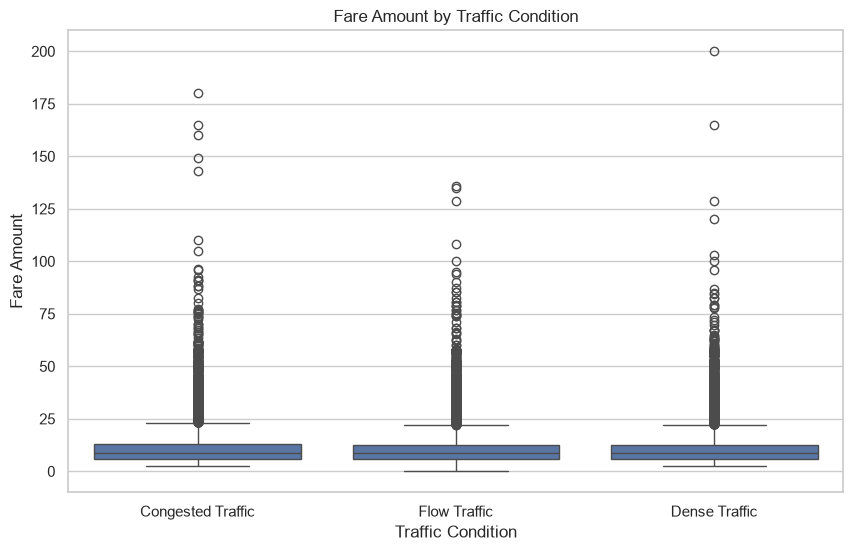

In [41]:
# Q4 - Traffic Condition vs Fare

plt.figure(figsize=(10, 6))

sns.boxplot(
    color="C0",
    data=df_eda,
    x="Traffic Condition",
    y="fare_amount"
)

plt.xlabel("Traffic Condition")
plt.ylabel("Fare Amount")
plt.title("Fare Amount by Traffic Condition")

plt.show()

In [42]:
df_eda.groupby("Traffic Condition")["fare_amount"].mean().sort_values(
    ascending=False
).round(2)

Traffic Condition
Congested Traffic   11.470
Dense Traffic       11.320
Flow Traffic        11.300
Name: fare_amount, dtype: float64

### Interpretation

The boxplot shows considerable overlap between fare distributions across the traffic-condition categories.

The average fares are **11.47** for Congested Traffic, **11.32** for Dense Traffic, and **11.30** for Flow Traffic.

The differences are relatively small, so traffic condition alone does not show a large difference in fare amount in this sample.

## Question 5: Is Distance the Strongest Predictor of Fare?

### Variables
- `distance`
- `fare_amount`

### Plot Choice
A scatter plot is used because both variables are numerical.

### Objective
To investigate the relationship between trip distance and fare amount.

Note:
Extreme distance values identified during data quality assessment are
retained because they were not confirmed to be invalid automatically.

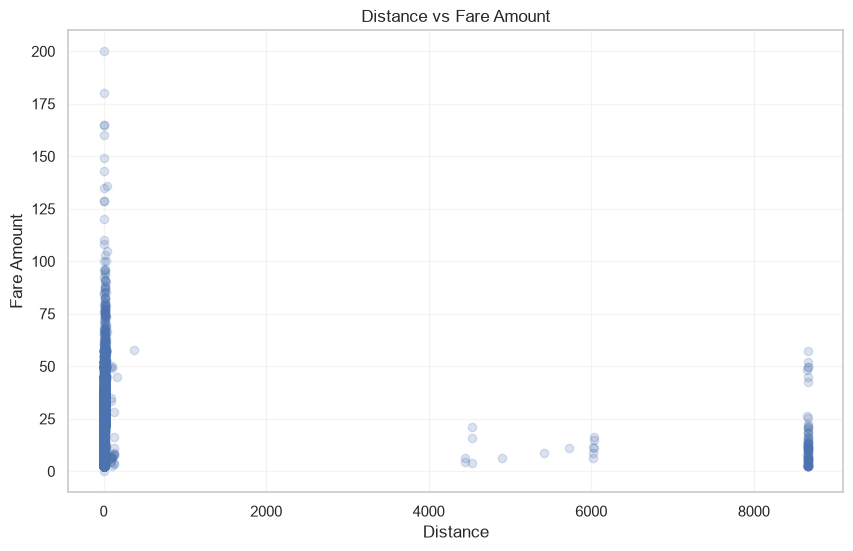

In [43]:
# Q5 - Distance vs Fare

plt.figure(figsize=(10, 6))

plt.scatter(
    df_eda["distance"],
    df_eda["fare_amount"],
    alpha=0.2
)

plt.xlabel("Distance")
plt.ylabel("Fare Amount")
plt.title("Distance vs Fare Amount")
plt.grid(alpha=0.2)

plt.show()

In [44]:
df_eda[["distance", "fare_amount"]].corr().round(3)

,distance,fare_amount
distance,1.000,0.016
fare_amount,0.016,1.000


In [45]:
# Q5 - Robust Distance/Fare Analysis

# Raw Pearson correlation is kept as the unfiltered baseline.
raw_pearson = df_eda["distance"].corr(df_eda["fare_amount"], method="pearson")
raw_spearman = df_eda["distance"].corr(df_eda["fare_amount"], method="spearman")

# Analytical robustness filter: retain trips with distance <= 50 km.
# This is NOT a claim that trips above 50 km are invalid.
df_distance_analysis = df_eda[df_eda["distance"] <= 50].copy()

filtered_pearson = df_distance_analysis["distance"].corr(
    df_distance_analysis["fare_amount"], method="pearson"
)
filtered_spearman = df_distance_analysis["distance"].corr(
    df_distance_analysis["fare_amount"], method="spearman"
)

# Non-zero, finite coordinates provide a separate geographic-quality check.
coordinate_columns = [
    "pickup_longitude", "pickup_latitude",
    "dropoff_longitude", "dropoff_latitude"
]
valid_geo_mask = (
    df_eda[coordinate_columns].notna().all(axis=1)
    & (df_eda[coordinate_columns] != 0).all(axis=1)
)

df_valid_geo = df_eda.loc[valid_geo_mask].copy()
df_robust = df_distance_analysis.loc[
    df_distance_analysis.index.isin(df_valid_geo.index)
].copy()

robust_geo_pearson = df_robust["distance"].corr(
    df_robust["fare_amount"], method="pearson"
)
robust_geo_spearman = df_robust["distance"].corr(
    df_robust["fare_amount"], method="spearman"
)

print(f"Raw Pearson correlation: {raw_pearson:.3f}")
print(f"Raw Spearman correlation: {raw_spearman:.3f}")
print(f"Distance <= 50 km rows: {len(df_distance_analysis):,}")
print(f"Pearson after Distance <= 50 km: {filtered_pearson:.3f}")
print(f"Spearman after Distance <= 50 km: {filtered_spearman:.3f}")
print(f"Valid non-zero coordinate rows: {len(df_valid_geo):,}")
print(f"Valid coordinates + Distance <= 50 km rows: {len(df_robust):,}")
print(f"Pearson with valid coordinates + Distance <= 50 km: {robust_geo_pearson:.3f}")
print(f"Spearman with valid coordinates + Distance <= 50 km: {robust_geo_spearman:.3f}")


Raw Pearson correlation: 0.016
Raw Spearman correlation: 0.811
Distance <= 50 km rows: 49,872
Pearson after Distance <= 50 km: 0.833
Spearman after Distance <= 50 km: 0.815
Valid non-zero coordinate rows: 48,992
Valid coordinates + Distance <= 50 km rows: 48,958
Pearson with valid coordinates + Distance <= 50 km: 0.849
Spearman with valid coordinates + Distance <= 50 km: 0.844


### Robustness Check: Distance vs Fare

The raw Pearson correlation is approximately **0.016**, but the raw data contains extreme distance observations that can distort a linear correlation.

Using a separate analytical dataframe with **Distance <= 50 km** increases the Pearson correlation to approximately **0.833** and the Spearman correlation to approximately **0.815**. Restricting further to records with non-zero, finite pickup and drop-off coordinates gives a Pearson correlation of approximately **0.849**.

The `Distance <= 50 km` condition is an **analytical robustness filter**, not a claim that every trip above 50 km is invalid. No rows were removed from `df_eda`, and the original `df` remains unchanged.

Among the selected numerical ride/time features examined in this robustness check, distance has the strongest linear association with fare after the extreme-distance observations are controlled for. This supports treating distance as an important candidate feature for Task 2, but it is **not by itself a proof of predictive performance or causality**.


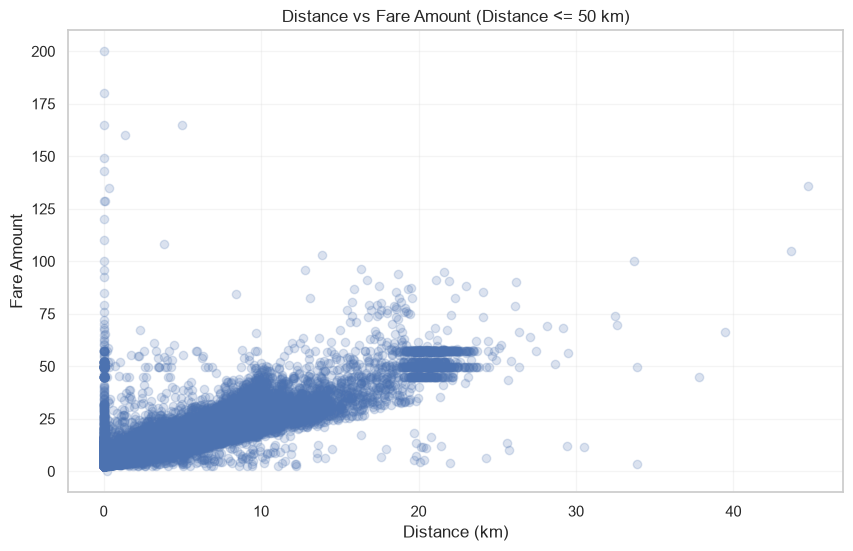

In [46]:
# Q5 - Robust Distance vs Fare (Distance <= 50 km)

plt.figure(figsize=(10, 6))
plt.scatter(
    df_distance_analysis["distance"],
    df_distance_analysis["fare_amount"],
    alpha=0.2
)
plt.xlabel("Distance (km)")
plt.ylabel("Fare Amount")
plt.title("Distance vs Fare Amount (Distance <= 50 km)")
plt.grid(alpha=0.2)
plt.show()


### Comparison with Other Numerical Features

To address the word **"strongest"** in the question without turning EDA into a full modeling exercise, the analysis compares the absolute Pearson correlations of selected numerical ride, distance, and time features with `fare_amount`. The comparison is shown for both the raw EDA data and the `Distance <= 50 km` robustness sample.


In [47]:
# Compare selected numerical features with Fare
comparison_features = [
    "distance", "jfk_dist", "ewr_dist", "lga_dist",
    "sol_dist", "nyc_dist", "passenger_count",
    "hour", "month", "year"
]

raw_feature_corr = (
    df_eda[comparison_features + ["fare_amount"]]
    .corr()["fare_amount"]
    .drop("fare_amount")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

robust_feature_corr = (
    df_distance_analysis[comparison_features + ["fare_amount"]]
    .corr()["fare_amount"]
    .drop("fare_amount")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

feature_comparison = pd.DataFrame({
    "Raw Pearson": raw_feature_corr,
    "Pearson (Distance <= 50 km)": robust_feature_corr
})

feature_comparison.round(3)


,Raw Pearson,Pearson (Distance <= 50 km)
distance,0.016,0.833
ewr_dist,0.005,0.004
hour,-0.022,-0.022
jfk_dist,0.003,0.002
lga_dist,0.004,0.003
month,0.027,0.027
nyc_dist,0.005,0.004
passenger_count,0.017,0.017
sol_dist,0.005,0.004
year,0.121,0.121


### Interpretation

The raw Pearson correlation between trip distance and fare amount is approximately **0.016**. However, the data-quality assessment identified extreme distance observations that can strongly affect this raw linear measure.

After applying the separate analytical robustness filter `Distance <= 50 km`, the Pearson correlation increases to approximately **0.833**. Using non-zero, finite pickup/drop-off coordinates together with the same distance filter increases it further to approximately **0.849**.

Therefore, the raw Pearson correlation should not be interpreted as evidence that distance has a weak relationship with fare. After accounting for extreme distance observations, trip distance shows a strong linear association with fare amount.

This is an observational EDA finding and does not establish causality or guarantee predictive performance.


## Question 6: What Is the Most Frequent Ride Request Hour?

### Variable
- `hour`

### Plot Choice
A count plot is appropriate because we want to compare the frequency
of ride requests across discrete hour categories.

### Objective
To identify the hours with the highest number of ride requests.
### Cleaning / Analysis Note
Ride counts are calculated from the positive-fare EDA dataset. This question measures demand frequency, not fare level.


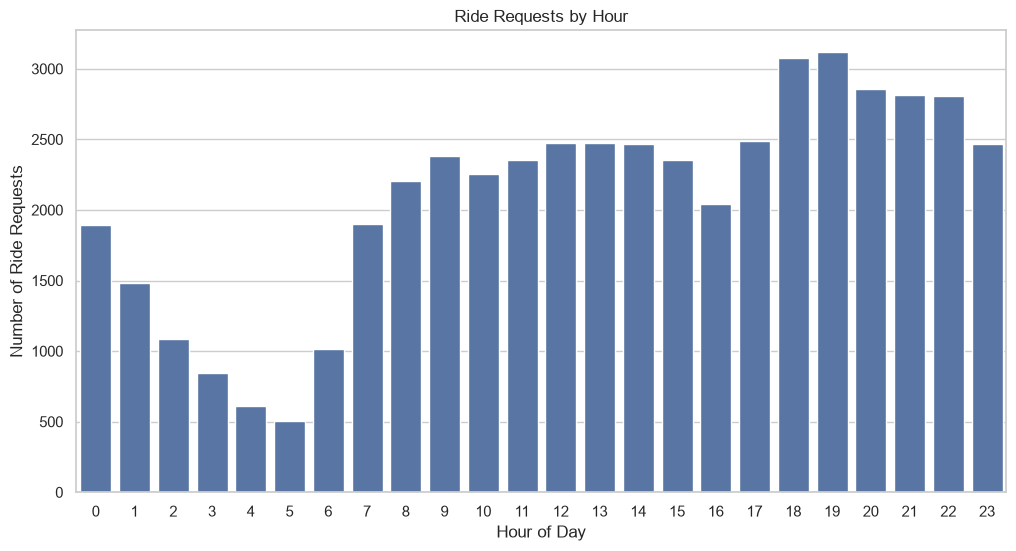

In [48]:
# Q6 - Ride Requests by Hour

plt.figure(figsize=(12, 6))

sns.countplot(
    color="C0",
    data=df_eda,
    x="hour"
)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Ride Requests")
plt.title("Ride Requests by Hour")
plt.xticks(range(24))

plt.show()

In [49]:
df_eda["hour"].value_counts().sort_values(
    ascending=False
).head(5)

hour
19    3117
18    3077
20    2859
21    2816
22    2808
Name: count, dtype: int64

### Interpretation

The count plot shows that ride requests are not evenly distributed across the hours of the day.

The most frequent request hour is **19:00 (7 PM)**, with **3,117 requests**, followed by 18:00 and 20:00.

This is a **demand** result: Q6 identifies when the most rides are requested, while Q3 identifies when the observed average fare is highest. These are different questions and should not be interpreted as the same pattern.


## Question 7: Does Weather Influence Average Trip Distance?

### Variables
- `Weather`
- `distance`

### Plot Choice
A boxplot is used to compare the distribution of trip distances across
different weather conditions.

### Objective
To investigate whether trip distance varies across weather conditions.
### Cleaning / Analysis Note
No distance outliers are removed for the primary plot. Because extreme distances can strongly affect the mean, median distance is also reported for context.


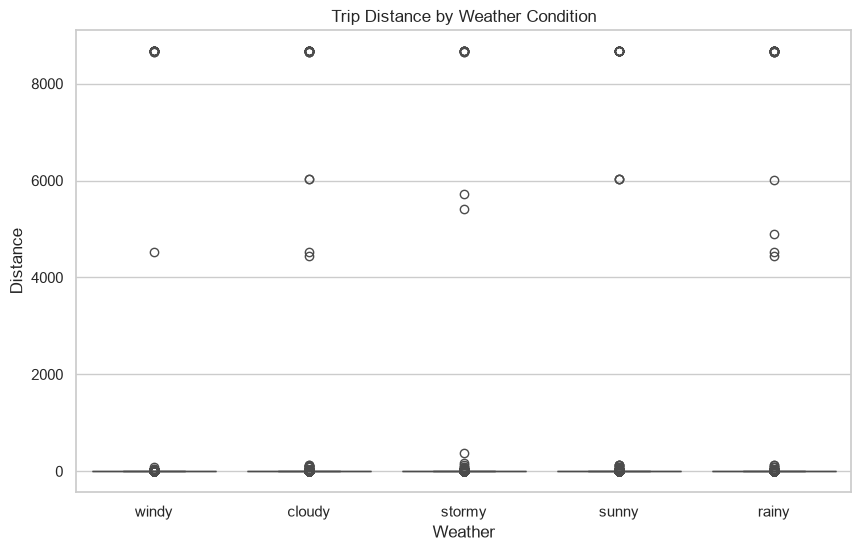

In [50]:
# ============================================================
# Q7 - Weather vs Distance
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    color="C0",
    data=df_eda,
    x="Weather",
    y="distance"
)

plt.xlabel("Weather")
plt.ylabel("Distance")
plt.title("Trip Distance by Weather Condition")

plt.show()

In [51]:
df_eda.groupby("Weather")["distance"].mean().sort_values(
    ascending=False
).round(2)

Weather
cloudy   22.960
rainy    19.210
sunny    18.840
windy    18.470
stormy   12.270
Name: distance, dtype: float64

In [52]:
# Q7 - Mean and Median Distance by Weather

weather_distance_summary = (
    df_eda.groupby("Weather")["distance"]
    .agg(mean_distance="mean", median_distance="median", ride_count="size")
    .sort_values("mean_distance", ascending=False)
)

weather_distance_summary.round(2)


,mean_distance,median_distance,ride_count
Weather,,,
cloudy,22.960,2.110,9903
rainy,19.210,2.170,10009
sunny,18.840,2.100,10108
windy,18.470,2.120,9955
stormy,12.270,2.110,10016


### Interpretation

The boxplot shows differences in the distributions of trip distance across weather categories. The **mean** distance is highest for **cloudy weather (22.96 km)** and lowest for **stormy weather (12.27 km)**.

However, the median distances are all close to about **2.1–2.2 km**. This shows that the large differences in the means are strongly influenced by extreme distance observations rather than a large shift in the typical trip distance.

Therefore, weather shows some differences in the raw mean distance, but the median and boxplot suggest that the typical trip distance is much more similar across weather categories. This is an association in the observed data, not evidence of causality.


## Question 8: Are Trips Closer to Airports More Expensive?

### Variables
- `fare_amount`
- `jfk_dist`
- `ewr_dist`
- `lga_dist`

### Plot Choice
Scatter plots are used to investigate the relationship between distance
from each airport and fare amount.

### Objective
To examine whether fare amounts vary with the distance from the major
airports.
### Cleaning / Analysis Note
The primary analysis retains the observed airport-distance values. A separate robustness check uses only records with non-zero, finite pickup and drop-off coordinates; this does not modify `df_eda`.


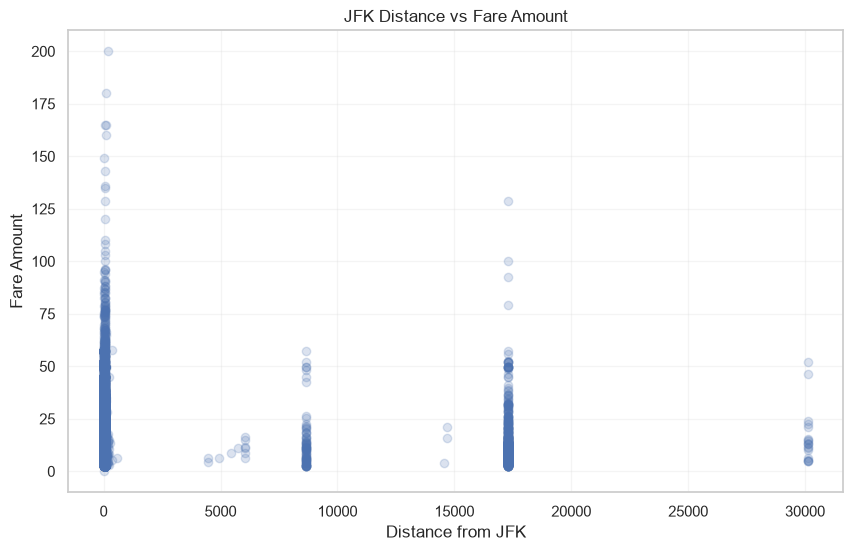

In [53]:
# Q8 - JFK Distance vs Fare

plt.figure(figsize=(10, 6))

plt.scatter(
    df_eda["jfk_dist"],
    df_eda["fare_amount"],
    alpha=0.2
)

plt.xlabel("Distance from JFK")
plt.ylabel("Fare Amount")
plt.title("JFK Distance vs Fare Amount")
plt.grid(alpha=0.2)

plt.show()

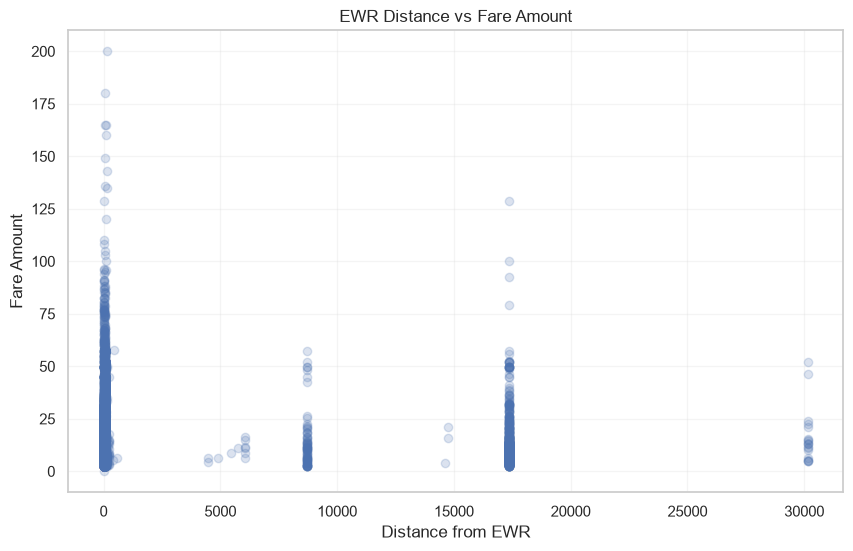

In [54]:
# Q8 - EWR Distance vs Fare

plt.figure(figsize=(10, 6))

plt.scatter(
    df_eda["ewr_dist"],
    df_eda["fare_amount"],
    alpha=0.2
)

plt.xlabel("Distance from EWR")
plt.ylabel("Fare Amount")
plt.title("EWR Distance vs Fare Amount")
plt.grid(alpha=0.2)

plt.show()

In [55]:
# Airport Distance Correlations

df_eda[
    [
        "fare_amount",
        "jfk_dist",
        "ewr_dist",
        "lga_dist"
    ]
].corr()["fare_amount"].sort_values(ascending=False).round(3)

fare_amount   1.000
ewr_dist      0.005
lga_dist      0.004
jfk_dist      0.003
Name: fare_amount, dtype: float64

In [56]:
# Q8 - Airport Distance Robustness Check

coordinate_columns = [
    "pickup_longitude", "pickup_latitude",
    "dropoff_longitude", "dropoff_latitude"
]

valid_geo_mask = (
    df_eda[coordinate_columns].notna().all(axis=1)
    & (df_eda[coordinate_columns] != 0).all(axis=1)
)
df_valid_geo = df_eda.loc[valid_geo_mask].copy()

raw_airport_corr = df_eda[["jfk_dist", "ewr_dist", "lga_dist", "fare_amount"]].corr()["fare_amount"]
robust_airport_corr = df_valid_geo[["jfk_dist", "ewr_dist", "lga_dist", "fare_amount"]].corr()["fare_amount"]

airport_comparison = pd.DataFrame({
    "Raw Pearson": raw_airport_corr,
    "Non-zero finite coordinates": robust_airport_corr
}).drop(index="fare_amount")

print(f"Rows with non-zero, finite pickup/drop-off coordinates: {len(df_valid_geo):,}")
airport_comparison.round(3)


Rows with non-zero, finite pickup/drop-off coordinates: 48,992


,Raw Pearson,Non-zero finite coordinates
jfk_dist,0.003,0.007
ewr_dist,0.005,0.014
lga_dist,0.004,0.011


### Interpretation

The raw airport-distance correlations with fare amount are all very close to zero: **EWR = 0.005**, **LGA = 0.004**, and **JFK = 0.003**.

A robustness check using records with non-zero, finite pickup and drop-off coordinates still produces small correlations (approximately **JFK = 0.007**, **EWR = 0.014**, and **LGA = 0.011**).

These results do not show a strong **linear** association between the airport-distance variables and fare in this dataset. Because the geographic fields contain suspicious coordinate records, this should be interpreted as a data-quality limitation rather than a claim that airport proximity has no effect on fares.


## Correlation Analysis

A correlation heatmap is used to summarize the linear relationships
between the main numerical variables.

This provides an overall view of which numerical variables have stronger
or weaker relationships with `fare_amount`.

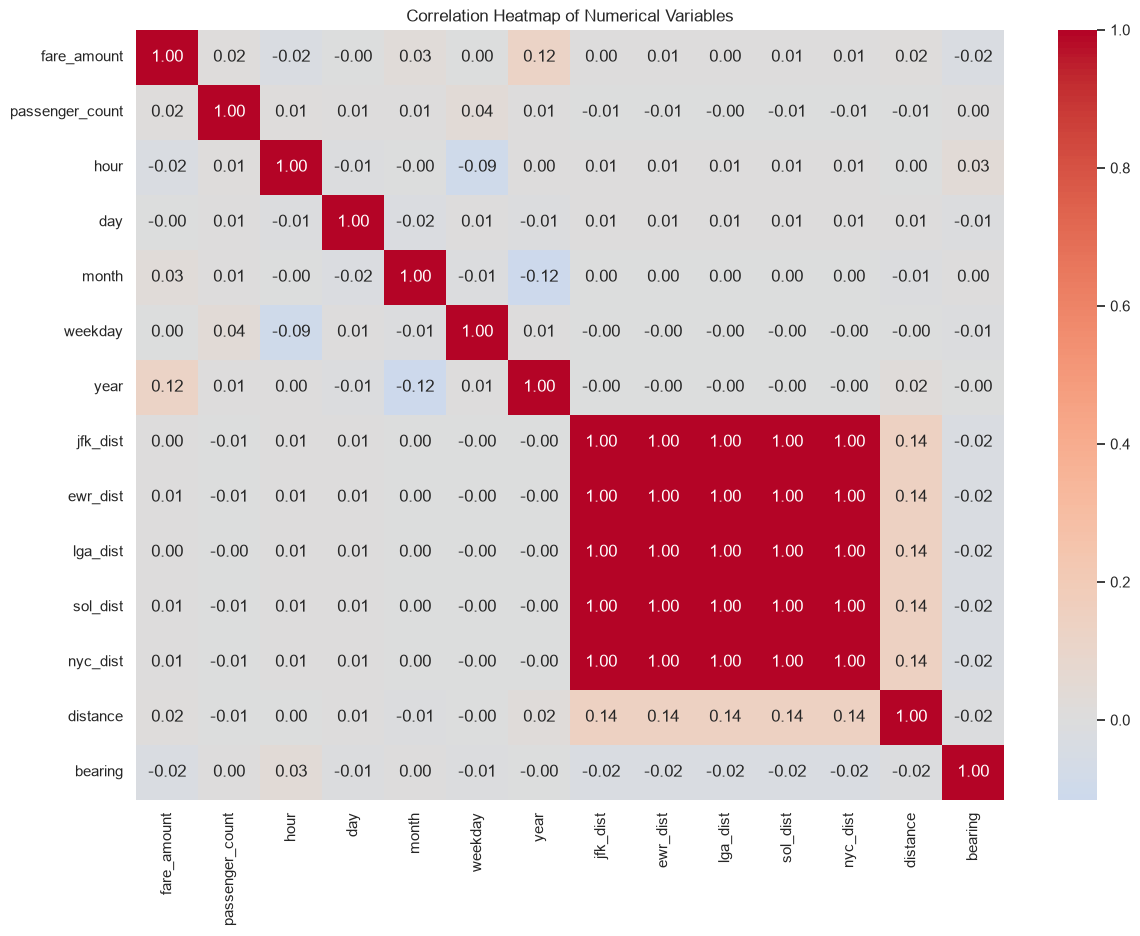

In [57]:
# Correlation Heatmap

numeric_columns = [
    "fare_amount",
    "passenger_count",
    "hour",
    "day",
    "month",
    "weekday",
    "year",
    "jfk_dist",
    "ewr_dist",
    "lga_dist",
    "sol_dist",
    "nyc_dist",
    "distance",
    "bearing"
]

correlation_matrix = df_eda[numeric_columns].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

In [58]:
# Final EDA Summary

summary = {
    "Original rows": len(df),
    "Rows used for EDA": len(df_eda),
    "Excluded non-positive fares": int((df["fare_amount"] <= 0).sum()),
    "Zero passenger records": int((df["passenger_count"] == 0).sum()),
    "Zero-distance records": int((df["distance"] == 0).sum()),
    "All-zero coordinate records": int(
        ((df["pickup_longitude"] == 0)
         & (df["pickup_latitude"] == 0)
         & (df["dropoff_longitude"] == 0)
         & (df["dropoff_latitude"] == 0)).sum()
    ),
    "Distinct duplicated keys": int((df["key"].value_counts() > 1).sum()),
    "Rows involved in duplicated keys": int(df["key"].value_counts().loc[lambda s: s > 1].sum()),
    "Passenger-Fare Pearson": df_eda["passenger_count"].corr(df_eda["fare_amount"]),
    "Distance-Fare raw Pearson": raw_pearson,
    "Distance-Fare raw Spearman": raw_spearman,
    "Distance-Fare Pearson (<=50 km)": filtered_pearson,
    "Distance-Fare Pearson (valid geo + <=50 km)": robust_geo_pearson,
    "Highest observed average fare hour": int(hourly_fare.loc[hourly_fare["fare_amount"].idxmax(), "hour"]),
    "Highest observed average fare": float(hourly_fare["fare_amount"].max()),
    "Most frequent request hour": int(df_eda["hour"].value_counts().idxmax()),
    "Most frequent request count": int(df_eda["hour"].value_counts().max()),
}

pd.Series(summary).round(3)


Original rows                                 50,000.000
Rows used for EDA                             49,991.000
Excluded non-positive fares                        9.000
Zero passenger records                           165.000
Zero-distance records                          1,449.000
All-zero coordinate records                      914.000
Distinct duplicated keys                         441.000
Rows involved in duplicated keys                 886.000
Passenger-Fare Pearson                             0.017
Distance-Fare raw Pearson                          0.016
Distance-Fare raw Spearman                         0.811
Distance-Fare Pearson (<=50 km)                    0.833
Distance-Fare Pearson (valid geo + <=50 km)        0.849
Highest observed average fare hour                 5.000
Highest observed average fare                     15.373
Most frequent request hour                        19.000
Most frequent request count                    3,117.000
dtype: float64

# Final EDA Insights

The exploratory analysis uses **49,991 positive-fare records** from an original **50,000-row** sample. Nine non-positive fare records were excluded from fare-based EDA, while the original `df` remains unchanged.

### Main Findings

- **Q1 — Passenger count:** The Pearson correlation with fare is approximately **0.017**, indicating a very weak linear association in this sample.
- **Q2 — Car condition:** Average fares are close across categories: Bad ≈ **$11.49**, Very Good ≈ **$11.44**, Good ≈ **$11.31**, Excellent ≈ **$11.22**. The distributions overlap substantially.
- **Q3 — Fare by hour:** **5 AM** has the highest observed average fare at approximately **$15.37**, based on **507 rides**. The smaller sample size at that hour is an important caveat.
- **Q4 — Traffic:** Average fares are close across traffic groups: Congested ≈ **$11.47**, Dense ≈ **$11.32**, Flow ≈ **$11.30**.
- **Q5 — Distance:** The raw Pearson correlation is only **0.016**, but extreme distance observations strongly affect the raw linear measure. With the separate analytical filter `Distance <= 50 km`, Pearson rises to approximately **0.833**; using non-zero, finite coordinates as an additional geographic-quality check gives approximately **0.849**. This makes distance an important candidate feature for modeling, without claiming causality or guaranteed predictive performance.
- **Q6 — Demand:** The highest request volume occurs at **7 PM (19:00)** with **3,117 rides**. This is a demand result and is different from Q3's average-fare result.
- **Q7 — Weather and distance:** Raw mean distance varies substantially by weather, but median distance is around **2.1–2.2 km** across all weather groups. The mean differences are therefore strongly influenced by extreme distance observations.
- **Q8 — Airport distance:** Raw correlations with fare are very small (JFK ≈ **0.003**, EWR ≈ **0.005**, LGA ≈ **0.004**). A non-zero, finite-coordinate robustness check remains small, so no strong linear association is observed in this dataset.

### Data Quality Limitations

- The dataset contains **165 zero-passenger records**. They were investigated but not automatically removed.
- There are **1,449 zero-distance records**, all with matching pickup and drop-off coordinates.
- There are **914 records where all four pickup/drop-off coordinates are zero**.
- Distance contains extreme observations, so raw means and raw Pearson correlations can be sensitive to those records.
- The PDF describes `key` as a unique trip ID, but the actual dataset contains **441 distinct duplicated keys involving 886 rows**, and `key` matches `pickup_datetime` for **100%** of rows. Duplicate keys were documented rather than arbitrarily deleted.
- Actual CSV category values are used as-is; they are not overwritten to match the simplified category examples in the task description.

### Overall EDA Takeaway

The analysis shows that simple linear relationships between fare and passenger count, car condition, traffic condition, and airport distance are weak in the raw sample. Distance requires special attention because extreme observations substantially distort the raw correlation; after a clearly labeled robustness check, distance shows a strong linear association with fare. These findings provide useful candidates and data-quality considerations for the next modeling stage without making causal claims.


## Further Questions for Deeper Analysis

The official task asks for new questions that build on the completed EDA. The following questions are intentionally limited to a small, useful set.

### 1. Does average fare differ between weekdays and weekends?
**Why it matters:** This can reveal whether demand timing is associated with different fare levels across the weekly cycle.

**Suggested plot:** Bar plot of average fare by weekday/weekend group.

### 2. Does traffic condition affect fare differently at different hours?
**Why it matters:** The overall traffic comparison is small, so the relationship may vary by time of day.

**Suggested plot:** Heatmap or grouped line plot of average fare by hour and traffic condition.

### 3. How does average trip distance change throughout the day?
**Why it matters:** Q6 identifies demand peaks, while this question checks whether trip length also changes by hour.

**Suggested plot:** Line plot of median or trimmed-mean distance by hour.

### 4. Which day of the week has the highest average fare?
**Why it matters:** This extends the time-based analysis beyond hour of day.

**Suggested plot:** Bar plot of average fare by weekday.

These are proposed follow-up questions, not additional completed analyses.


## Submission Checklist

### Official Task Requirements
- [x] Dataset loaded and inspected
- [x] Missing values checked
- [x] Duplicate records checked
- [x] `key` column investigated and discrepancy documented
- [x] Fare-quality issues investigated
- [x] Passenger-count anomalies investigated
- [x] Zero-distance and geographic-coordinate issues investigated
- [x] Extreme distance values investigated
- [x] Categorical values inspected using the actual CSV categories
- [x] Q1–Q8 completed with appropriate visualizations
- [x] Plot choice and rationale documented for Q1–Q8
- [x] Cleaning / analysis notes documented
- [x] Code is clean and commented
- [x] Interpretation included for Q1–Q8
- [x] Q5 includes raw and robustness analysis
- [x] Q7 includes mean and median context
- [x] Q8 includes a clearly labeled coordinate-quality robustness check
- [x] New follow-up questions proposed
- [x] Final EDA insights and limitations documented

### Data Integrity
- [x] Original `df` preserved
- [x] `df_eda` used for positive-fare EDA
- [x] Robustness checks use separate dataframes (`df_distance_analysis`, `df_valid_geo`, `df_robust`)
- [x] No automatic deletion of statistical outliers
- [x] No arbitrary deletion of duplicate keys
- [x] No model training or prediction changes

### Presentation Requirement
- [x] Presentation-ready EDA story prepared separately from the notebook

The notebook is structured to satisfy the official Task 1 EDA requirements while preserving the original analysis and keeping robustness checks separate from the main dataset.


In [59]:
# Final QA and CSV Export

# Confirm the original dataframe was not overwritten and the EDA dataset has the expected size.
assert len(df) == 50_000, "Original df row count changed."
assert len(df_eda) == 49_991, "Unexpected df_eda row count."
assert (df_eda["fare_amount"] > 0).all(), "Non-positive fare found in df_eda."

# Export the current EDA dataset.
df_eda.to_csv("uber_fare_eda_clean.csv", index=False)

print("Final QA passed.")
print(f"Original df rows: {len(df):,}")
print(f"EDA rows exported: {len(df_eda):,}")
print("df was preserved; no model was trained or modified in this notebook.")
print("CSV exported: uber_fare_eda_clean.csv")


Final QA passed.
Original df rows: 50,000
EDA rows exported: 49,991
df was preserved; no model was trained or modified in this notebook.
CSV exported: uber_fare_eda_clean.csv
